In [4]:
# STEP 1
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import os
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression



#  LOAD DATASET

DATA_PATH = r"E:\IDS IPS Project\data\selected_features_dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f" Loaded dataset shape: {df.shape}")
print(f" Label distribution:\n{df['Label'].value_counts()}")


 Loaded dataset shape: (25306, 16)
 Label distribution:
Label
DDoS             4000
BENIGN           4000
DoS GoldenEye    3999
DoS Hulk         3998
DoS slowloris    3846
FTP-Patator      2889
SSH-Patator      2574
Name: count, dtype: int64


In [5]:
# STEP 2
#  SPLIT FEATURES & LABEL

X = df.drop(columns=["Label"])
y = df["Label"]

# Encode target labels to numeric
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

# Create models directory
os.makedirs(r"E:\IDS IPS Project\models", exist_ok=True)


Training shape: (20244, 15), Testing shape: (5062, 15)


In [6]:
# STEP 3
#  MODEL EVALUATION FUNCTION

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, label_encoder):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"\n {model_name} Performance:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # Save model
    model_bundle = {"model": model, "label_encoder": label_encoder}
    model_path = fr"E:\IDS IPS Project\models\{model_name.lower().replace(' ', '_')}_model.pkl"
    joblib.dump(model_bundle, model_path)
    print(f" Model saved at: {model_path}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

    



In [8]:
# STEP 4

results = []
trained_models = {}

# 1 RANDOM FOREST
rf = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
results.append(evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest", le))
trained_models["Random Forest"] = rf

# 2 XGBOOST
xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(np.unique(y_encoded)),
    random_state=42,
    n_jobs=-1
)
results.append(evaluate_model(xgb, X_train, y_train, X_test, y_test, "XGBoost", le))
trained_models["XGBoost"] = xgb

# 3 SVM
svm = SVC(kernel='rbf', C=2, gamma='scale', probability=True, random_state=42)
results.append(evaluate_model(svm, X_train, y_train, X_test, y_test, "SVM", le))
trained_models["SVM"] = svm

# 4 LOGISTIC REGRESSION
lr = LogisticRegression(max_iter=500, solver='lbfgs', multi_class='multinomial', n_jobs=-1)
results.append(evaluate_model(lr, X_train, y_train, X_test, y_test, "Logistic Regression", le))
trained_models["Logistic Regression"] = lr


# STEP 5
# COMPARISON TABLE

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\n Model Comparison:")
print(results_df)


# STEP 6
# SAVE BEST MODEL + FEATURES

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"\n Best Model Selected: {best_model_name}")

# Save best model
joblib.dump(best_model, r"E:\IDS IPS Project\models\best_model.pkl")

# Save feature columns
joblib.dump(X_train.columns.tolist(), r"E:\IDS IPS Project\models\features.pkl")

print(" Best model and features saved successfully!")


 Random Forest Performance:
Accuracy : 0.9964
Precision: 0.9965
Recall   : 0.9964
F1 Score : 0.9964
 Model saved at: E:\IDS IPS Project\models\random_forest_model.pkl

 XGBoost Performance:
Accuracy : 0.9962
Precision: 0.9962
Recall   : 0.9962
F1 Score : 0.9962
 Model saved at: E:\IDS IPS Project\models\xgboost_model.pkl

 SVM Performance:
Accuracy : 0.9739
Precision: 0.9743
Recall   : 0.9739
F1 Score : 0.9739
 Model saved at: E:\IDS IPS Project\models\svm_model.pkl


e:\Uers\Program Files\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 Logistic Regression Performance:
Accuracy : 0.9154
Precision: 0.9208
Recall   : 0.9154
F1 Score : 0.9159
 Model saved at: E:\IDS IPS Project\models\logistic_regression_model.pkl

 Model Comparison:
                 Model  Accuracy  Precision    Recall        F1
0        Random Forest  0.996444   0.996454  0.996444  0.996445
1              XGBoost  0.996247   0.996244  0.996247  0.996244
2                  SVM  0.973923   0.974288  0.973923  0.973927
3  Logistic Regression  0.915448   0.920772  0.915448  0.915922

 Best Model Selected: Random Forest
 Best model and features saved successfully!


In [10]:
# STEP 5
#  COMPARISON TABLE

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
display(results_df)


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.996444,0.996454,0.996444,0.996445
1,XGBoost,0.996247,0.996244,0.996247,0.996244
2,SVM,0.973923,0.974288,0.973923,0.973927
3,Logistic Regression,0.915448,0.920772,0.915448,0.915922


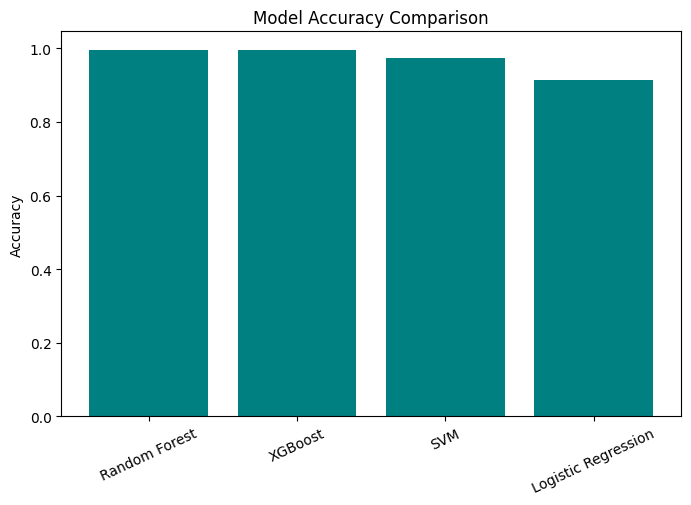

In [11]:
# STEP 6
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"], color="teal")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=25)
plt.show()
